**Visualizing Activations & Derivatives**
- **Task:** Using NumPy and Matplotlib, plot the graphs of Sigmoid, Tanh, ReLU, and LeakyReLU on one subplot. On a second subplot, plot the derivatives of these functions.
- **Why:** Visualizing the derivatives immediately shows you why "Vanishing Gradients" happen in Sigmoid/Tanh, and why ReLU solved it (but introduced "Dead ReLUs").

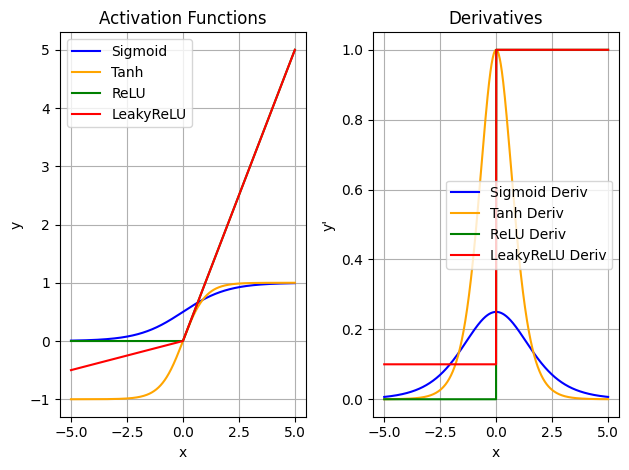

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define range for x
x = np.linspace(-5, 5, 1000)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x)**2

def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return np.where(x > 0, 1.0, 0.0)

def leaky_relu(x, alpha=0.1):
    return np.where(x > 0, x, alpha * x)

def leaky_relu_deriv(x, alpha=0.1):
    return np.where(x > 0, 1.0, alpha)

# Plotting Activation Functions
plt.subplot(1, 2, 1)
plt.plot(x, sigmoid(x), label='Sigmoid', color='blue')
plt.plot(x, tanh(x), label='Tanh', color='orange')
plt.plot(x, relu(x), label='ReLU', color='green')
plt.plot(x, leaky_relu(x), label='LeakyReLU', color='red')
plt.title('Activation Functions')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()

# Plotting Derivatives
plt.subplot(1, 2, 2)
plt.plot(x, sigmoid_deriv(x), label='Sigmoid Deriv', color='blue')
plt.plot(x, tanh_deriv(x), label='Tanh Deriv', color='orange')
plt.plot(x, relu_deriv(x), label='ReLU Deriv', color='green')
plt.plot(x, leaky_relu_deriv(x), label='LeakyReLU Deriv', color='red')
plt.title('Derivatives')
plt.xlabel('x')
plt.ylabel("y'")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**The Vanishing Gradient Experiment**
- **Task:** Build a very deep MLP (e.g., 10 layers). Train two versions on a simple classification task: one using Sigmoid activations and one using ReLU. Record the absolute mean of the gradients in the first layer over 20 epochs. Plot both on a Seaborn line chart.
- **Why:** Provides empirical, visual proof of the vanishing gradient problem and how modern activations mitigate it.

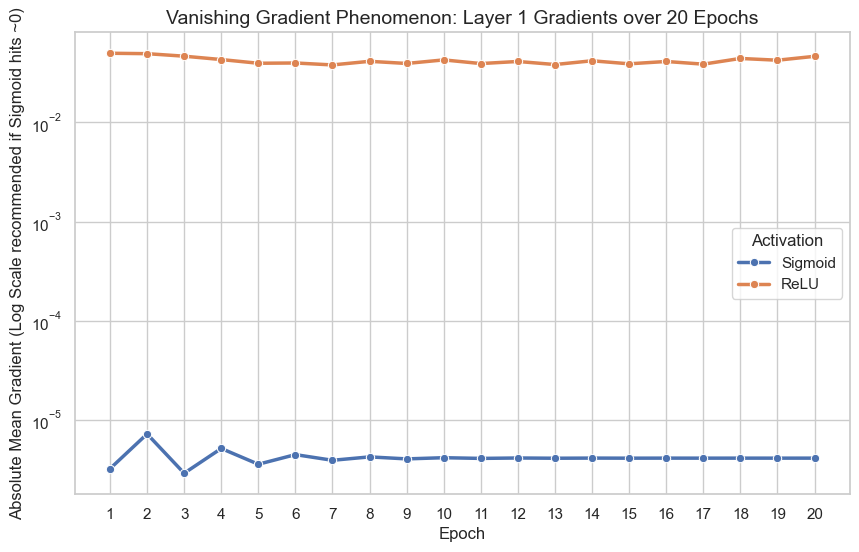

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate a synthetic dataset
np.random.seed(42)
X = np.random.randn(200, 10)
y = np.random.randint(0, 2, size=(200, 1))

# 2. Define Layer and Activation components for custom Backpropagation
class Layer:
    def __init__(self, input_dim, output_dim, activation_type):
        # Xavier/Glorot Initialization to ensure fair comparison
        self.W = np.random.randn(input_dim, output_dim) * np.sqrt(2.0 / (input_dim + output_dim))
        self.b = np.zeros((1, output_dim))
        self.activation_type = activation_type
        self.X_in = None
        self.A_out = None
        self.dW = None

    def forward(self, X_in):
        self.X_in = X_in
        Z = np.dot(X_in, self.W) + self.b
        if self.activation_type == 'sigmoid':
            self.A_out = 1 / (1 + np.exp(-np.clip(Z, -20, 20)))
        elif self.activation_type == 'relu':
            self.A_out = np.maximum(0, Z)
        return self.A_out

    def backward(self, dA_out):
        # Calculate derivative of activation
        if self.activation_type == 'sigmoid':
            dZ = dA_out * self.A_out * (1 - self.A_out)
        elif self.activation_type == 'relu':
            dZ = dA_out * (self.A_out > 0)
            
        self.dW = np.dot(self.X_in.T, dZ)
        dX_out = np.dot(dZ, self.W.T)
        return dX_out

# 3. Experiment Runner
def train_deep_mlp(activation_type, epochs=20):
    # Construct a 10-layer MLP (9 hidden layers + 1 output layer)
    layers = []
    layers.append(Layer(10, 16, activation_type))
    for _ in range(8):
        layers.append(Layer(16, 16, activation_type))
    layers.append(Layer(16, 1, 'sigmoid')) # Final classification layer
    
    first_layer_gradient_means = []

    for epoch in range(epochs):
        # Forward propagation
        out = X
        for layer in layers:
            out = layer.forward(out)
            
        # Binary Cross-Entropy Loss Derivative
        d_loss = (out - y) / (out * (1 - out) + 1e-15)
        
        # Backward propagation
        dA = d_loss
        for layer in reversed(layers):
            dA = layer.backward(dA)
            
        # Record the absolute mean of the gradients in the first layer
        first_layer_gradient_means.append(np.mean(np.abs(layers[0].dW)))
        
        # Update weights (Vanilla SGD)
        for layer in layers:
            layer.W -= 0.01 * layer.dW

    return first_layer_gradient_means

# 4. Collect and structure data
epochs = 20
sigmoid_grads = train_deep_mlp('sigmoid', epochs)
relu_grads = train_deep_mlp('relu', epochs)

df = pd.DataFrame({
    'Epoch': np.tile(np.arange(1, epochs + 1), 2),
    'Absolute Mean Gradient': sigmoid_grads + relu_grads,
    'Activation': ['Sigmoid'] * epochs + ['ReLU'] * epochs
})

# 5. Visualization with Seaborn
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")
sns.lineplot(data=df, x='Epoch', y='Absolute Mean Gradient', hue='Activation', marker='o', linewidth=2.5)

plt.title('Vanishing Gradient Phenomenon: Layer 1 Gradients over 20 Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Absolute Mean Gradient (Log Scale recommended if Sigmoid hits ~0)', fontsize=12)
plt.yscale('log')  # Uses a log scale to cleanly showcase the orders-of-magnitude difference
plt.xticks(range(1, epochs + 1))
plt.show()